In [ ]:
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

# Define the path to the src directory manually
src_path = os.path.abspath('../src')
sys.path.insert(0, src_path)

from module_tidal import TidalData
from module_rotor import RotorData
from module_rotor_simulation import RotorSimulation
from module_vessel import VesselData
from module_lcoe import LCOE
from module_constraint_checker import ConstraintChecker


from constUnitConvert import ConstantsUnitConversion
from constGlobal import ConstantsGlobal

CONVERT = ConstantsUnitConversion()
GLOBAL = ConstantsGlobal()


# Use color-blind friendly style
plt.style.use('tableau-colorblind10')

In [ ]:

# Define tidal data parameters
# station = "SEA0505"  # Site 2

station = "PCT3716"  # Site 2
startdate = 20200201  # yyyyMMdd
rangeHr = 2 * 7 * 24  # Two weeks
timestep = 5.0  # Timestep in seconds


In [ ]:

# Initialize TidalData class
tidal_data = TidalData(station, startdate, rangeHr, timestep)
flow_speeds, times, dmoor_m, lat_rad, lon_rad, station_name, nearest_city, cable_length = tidal_data.load_tidal_data("../data/AlaskaCityLatLong.txt")


/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Users/akeow/opt/anaconda3/envs/VITAL_env/lib/python3.12/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'proxy.sandia.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#t

Buoy lat:56.6765 degree
Buoy lon:-133.7325 degree
City lat:56.9653 degree
City lon:-134.1564 degree
City lat:0.9942320443863258 radian
City lon:-2.3414708926225205 radian
Buoy lat:0.9891915335065662 radian
Buoy lon:-2.3340724419233165 radian


50.0
0.9891915335065662
-2.3340724419233165
Summit Island, west of
Kake
25.623156076403998
41236.37


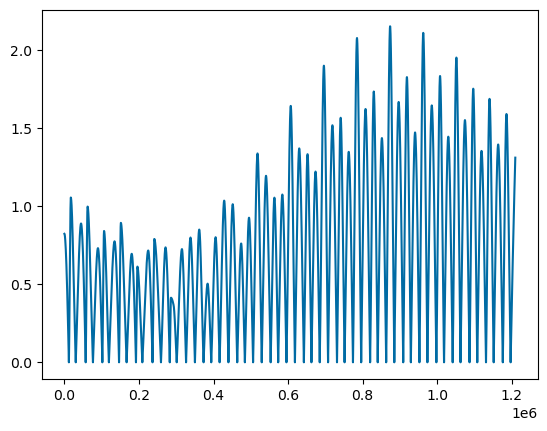

In [ ]:

plt.plot(times,flow_speeds)
print(dmoor_m)
print(lat_rad)
print(lon_rad)
print(station_name)
print(nearest_city)
print(cable_length*CONVERT.m2mile)
print(cable_length)

In [ ]:

# Define simulation parameters
config = {
    'Radius': 1.0,
    'Prated': 200000.0,
    'dCable': 10.0,
    'dMoor': dmoor_m,
    'Uinf': flow_speeds,
    't': times,
    'CpFunc': None,  # Placeholder, will be set later
    'CqFunc': None,  # Placeholder, will be set later
    'CtFunc': None,  # Placeholder, will be set later
    'CpOpt': None,  # Placeholder, will be set later
    'TSROpt': None,  # Placeholder, will be set later
    'Umin': 0.0,
    'withBrake': True,
    'control_strategy': 'optimal',
    'attachment_method': 'cable' 
}

# Initialize RotorData class
rotor_filename = "../data/Sitkana_rotor_data_blade_1.txt"
rotor_data = RotorData(rotor_filename)

# Set Cp, Cq, and Ct functions from RotorData class
config['CpFunc'] = rotor_data.get_cp
config['CqFunc'] = rotor_data.get_cq
config['CtFunc'] = rotor_data.get_ct

# Set CpOpt and TSROpt from RotorData class
config['CpOpt'] = rotor_data.CpOpt
config['TSROpt'] = rotor_data.TSROpt
config['TSRmax'] = rotor_data.TSRmax
config['efficiency'] = 0.9

config

rotor_data

In [ ]:
rotor_data.TSRmax
rotor_sim = RotorSimulation(config)


9.692400000000001e-05
2.08289676
 message: Solution found.
 success: True
  status: 0
     fun: -282.7423130090364
       x: 1.1893883792086124
     nit: 18
    nfev: 18


np.float64(1.1902682588571427)

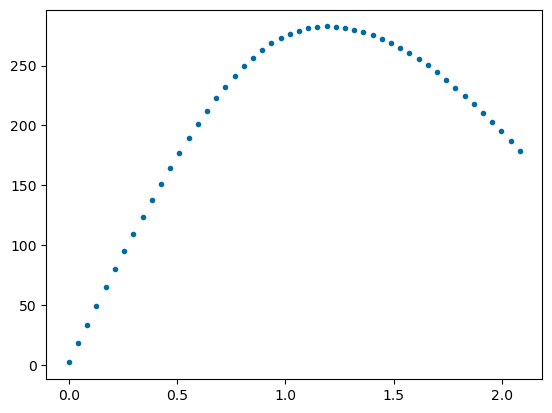

In [ ]:

possibleSpeed = rotor_sim.TSROpt * rotor_sim.Uinf / rotor_sim.Radius  # Assuming optimal TSR condition, what is the speed range
possibleSpeedRange = np.linspace(np.min(possibleSpeed), np.max(possibleSpeed), 50)  # Initial guess range
avePowerRange = -1 * np.array([rotor_sim.objectiveFunction_findOptimalConstantSpeed(ii, rotor_sim.Radius, rotor_sim.Uinf, rotor_sim.t, rotor_sim.CpFunc) for ii in possibleSpeedRange])
plt.plot(possibleSpeedRange,avePowerRange,'.')

maxspeed = np.argmax(rotor_sim.find_optimal_constant_speed())

positive_indices = np.where(avePowerRange > 0)[0]
min_Speed = possibleSpeedRange[positive_indices[0]]
max_Speed = possibleSpeedRange[positive_indices[-1]]

print(min_Speed)
print(max_Speed)
import scipy as sp
result = sp.optimize.minimize_scalar(rotor_sim.objectiveFunction_findOptimalConstantSpeed, bounds=(min_Speed, max_Speed), method='bounded', args=(rotor_sim.Radius, rotor_sim.Uinf, rotor_sim.t, rotor_sim.CpFunc))
print(result)

idx = np.argmax(avePowerRange)
possibleSpeedRange[idx]



In [ ]:

rotor_sim.simulate()
result = rotor_sim.get_results()

In [ ]:
result

{'t': array([0.000000e+00, 5.000000e+00, 1.000000e+01, ..., 1.209585e+06,
        1.209590e+06, 1.209595e+06], shape=(241920,)),
 'w': array([0.79671528, 0.79671528, 0.79671528, ..., 1.20142366, 1.2018731 ,
        1.20232241], shape=(241920,)),
 'Tc': array([237.08913251, 237.08913251, 237.08913197, ..., 539.13523229,
        539.53867966, 539.94216072], shape=(241920,)),
 'Pmech': array([188.89253459, 188.89253459, 188.89253395, ..., 647.72982273,
        648.45702556, 649.18456108], shape=(241920,)),
 'Pelec': array([170.00328113, 170.00328113, 170.00328056, ..., 582.95684046,
        583.611323  , 584.26610497], shape=(241920,)),
 'Phydro': array([188.89253459, 188.89239133, 188.89196166, ..., 755.72399177,
        756.46022679, 757.19677474], shape=(241920,)),
 'Pfluid': array([ 894.25050699,  894.24986463,  894.24793785, ..., 3604.64096324,
        3608.12726573, 3611.61504655], shape=(241920,)),
 'Punc': array([188.89253459, 188.89239891, 188.89199191, ..., 761.40831066,
       

max speed (RPM): 19.815974097216195
mean speed (RPM): 7.045322118797045
min speed (RPM): 1.6564810481723142
max torque (N): 1608.3976962779984
mean torque (N): 271.6103202685903
min torque (N): 11.239203469886144


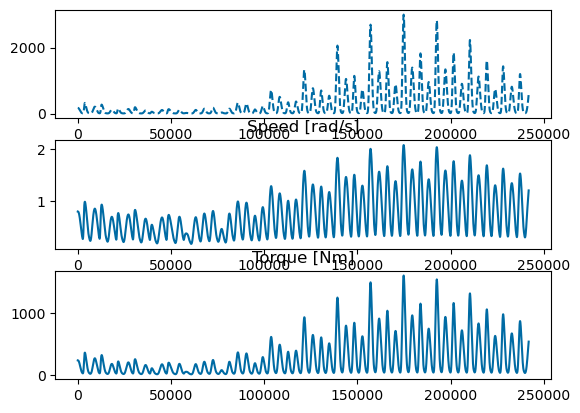

In [ ]:

plt.subplot(3,1,1)
plt.plot(result['Pelec'])

plt.subplot(3,1,2)
plt.plot(result['w'],'-') 
plt.title('Speed [rad/s]')

plt.subplot(3,1,3)
plt.plot(result['Tc'],'-') 
plt.title('Torque [Nm]')

print(f'max speed (RPM): {np.max(result['w']*CONVERT.rads2rpm)}')
print(f'mean speed (RPM): {np.average(result['w']*CONVERT.rads2rpm)}')
print(f'min speed (RPM): {np.min(result['w']*CONVERT.rads2rpm)}')

print(f'max torque (N): {np.max(result['Tc'])}')
print(f'mean torque (N): {np.average(result['Tc'])}')
print(f'min torque (N): {np.min(result['Tc'])}')


Text(0, 0.5, 'Torque [N]')

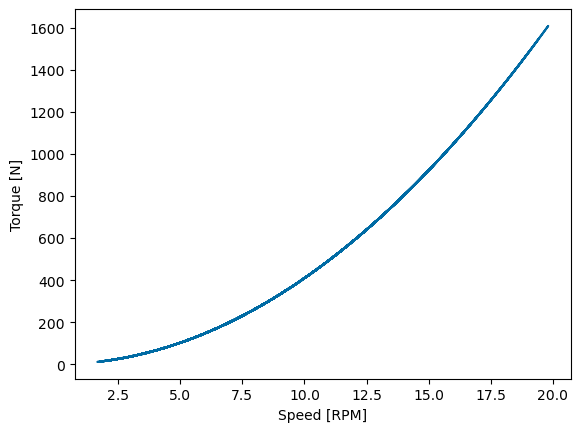

In [ ]:

plt.figure()
plt.plot(result['w']*CONVERT.rads2rpm,result['Tc'])
plt.xlabel('Speed [RPM]')
plt.ylabel('Torque [N]')

# Ship Design

In [ ]:

vessel = VesselData(
    height=0.5,
    density=500.0,
    theta_m=45 * np.pi / 180.0,
    alpha=4.0,
    Cd=0.25,
    phi=10 * np.pi / 180.0
)

In [ ]:

vessel.calculate_vessel_properties(result['Wturbine']/GLOBAL.g, result['Uinf_adjusted'], result['Ft'])

In [ ]:
print(vessel.height)

0.5


In [ ]:
result['Ft']

array([ 593.09913796,  593.09874814,  593.09757939, ..., 1550.64017733,
       1551.59451319, 1552.54895454], shape=(241920,))

In [ ]:
print(f"Width: {vessel.width:.2f} m")
print(f"Mooring Force: {vessel.Fmoor:.2f} N")
print(f"Length: {vessel.length:.2f} m")
print(f"Hydrostatic Stiffness (Khs): {vessel.Khs:.2f} N/m")
print(f"Hydrostatic Stiffness in Roll (Kphi): {vessel.Kphi:.2f} N*m/rad")
print(f"Metacentric Height (GM): {vessel.GM:.2f} m")
print(f"Vessel Volume: {vessel.VesselVolume:.2f} m^3")
print(f"Submerged Height (h_s): {vessel.h_s:.2f} m")

Width: 12.04 m
Mooring Force: 8278.68 N
Length: 48.15 m
Hydrostatic Stiffness (Khs): 5821885.31 N/m
Hydrostatic Stiffness in Roll (Kphi): 70114956.16 N*m/rad
Metacentric Height (GM): 48.17 m
Vessel Volume: 289.79 m^3
Submerged Height (h_s): 0.25 m


In [ ]:
Vessel_Drag_Force = vessel.calculate_vessel_drag_force(result['Uinf_adjusted'])
print(Vessel_Drag_Force)

[260.52198506 260.5218603  260.52148608 ... 659.85157518 660.27696595
 660.70240004]


In [ ]:
constraint_checker = ConstraintChecker(config['Radius'], rotor_data.get_cpmin)

if constraint_checker.check_depth_constraint(result['dHub']):
    print("Depth constraint is satisfied")

if constraint_checker.check_cavitation_constraint(result['TSR'], result['Uinf_adjusted'], result['w'], result['dHub']):
    print("Cavitation constraint is satisfied")

if constraint_checker.check_pitch_stiffness_constraint(vessel):
    print("Pitch stiff constraint is satisfied")
        
if constraint_checker.check_pitch_constraint(vessel, result['Uinf_adjusted'], result['Ft'],result['dHub']):
    print("Pitch stiff constraint is satisfied")

Depth constraint is satisfied
Cavitation constraint is satisfied
Pitch stiff constraint is satisfied
Pitch stiff constraint is satisfied


In [ ]:
lcoe_calculator = LCOE(config['Radius'], 
      config['Prated'], 
      number_of_turbines=1.0, 
      hub_depth = result['dHub'], 
      customer='customer_B', 
      application='battery_charging')
BatteryCapacity_kWh = 10
# Calculate total CAPEX
lcoe_calculator.set_instantaneous_power(result['Pelec'], result['t'])

total_capex = lcoe_calculator.calculate_total_capex(cable_length, 
                                                   dmoor_m, 
                                                   Vessel_Drag_Force, 
                                                   result['Ft'], 
                                                   vessel.VesselVolume, 
                                                   BatteryCapacity_kWh)

Individual CAPEX components:
anchor_cost: $3287.54
platform_cost: $2897902.09
charge_controller_cost: $2310.15
gearbox_cost: $824.01
concrete_cost: $1296.30
assembly_cost: $-9016.85
generator_cost: $-45584.25
rotor_cost: $503.43
steel_component_cost: $273.04
rotor_construction_cost: $214.85
battery_cost: $1500.00


In [ ]:
print(f"Total CAPEX: {total_capex[0]:.2f} USD")

annual_energy = lcoe_calculator.calculate_annual_energy()
print(f"Annual Energy: {annual_energy:.2f} kWh")

capacity_factor = lcoe_calculator.calculate_capacity_factor()
print(f"Capacity Factor: {capacity_factor:.2%}")

Total CAPEX: 2996185.83 USD
Annual Energy: 2576.16 kWh
Capacity Factor: 0.15%
